In [1]:
# load and combine the 7 dataset parts into one DataFrame
import glob
import pandas as pd

files = glob.glob("../data/raw/uwb_dataset_part*.csv")
print("Files found:", len(files), files)

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print("Dataset shape:", df.shape)

df.head()

Files found: 7 ['../dataset\\uwb_dataset_part1.csv', '../dataset\\uwb_dataset_part2.csv', '../dataset\\uwb_dataset_part3.csv', '../dataset\\uwb_dataset_part4.csv', '../dataset\\uwb_dataset_part5.csv', '../dataset\\uwb_dataset_part6.csv', '../dataset\\uwb_dataset_part7.csv']
Dataset shape: (42000, 1031)


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,0.0,3.90,745.0,18712.0,10250.0,11576.0,64.0,11855.0,967.0,611.0,...,279.0,458.0,183.0,158.0,198.0,87.0,296.0,505.0,307.0,0.0
1,0.0,0.66,749.0,11239.0,6313.0,4712.0,64.0,18968.0,1133.0,447.0,...,144.0,334.0,290.0,228.0,187.0,213.0,202.0,89.0,103.0,0.0
2,1.0,7.86,746.0,4355.0,5240.0,3478.0,60.0,14699.0,894.0,723.0,...,32.0,373.0,224.0,174.0,124.0,329.0,207.0,96.0,218.0,0.0
3,1.0,3.48,750.0,8502.0,8416.0,5890.0,76.0,8748.0,1127.0,1024.0,...,252.0,173.0,198.0,160.0,434.0,397.0,290.0,155.0,342.0,256.0
4,0.0,1.19,746.0,17845.0,18095.0,12058.0,68.0,11380.0,1744.0,276.0,...,154.0,209.0,242.0,296.0,87.0,178.0,314.0,247.0,292.0,256.0


In [2]:
# integrity check
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Class balance:\n", df["NLOS"].value_counts())

Missing values: 0
Duplicate rows: 0
Class balance:
 NLOS
0.0    21000
1.0    21000
Name: count, dtype: int64


In [3]:
# select only the 14 scalar features
feature_cols = [
    'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
    'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
    'CH', 'FRAME_LEN', 'PREAM_LEN', 'BITRATE', 'PRFR'
]

X = df[feature_cols]
y = df["NLOS"]

print("X shape:", X.shape)  # should be (42000, 14)
print("y shape:", y.shape)  # should be (42000,)

X shape: (42000, 14)
y shape: (42000,)


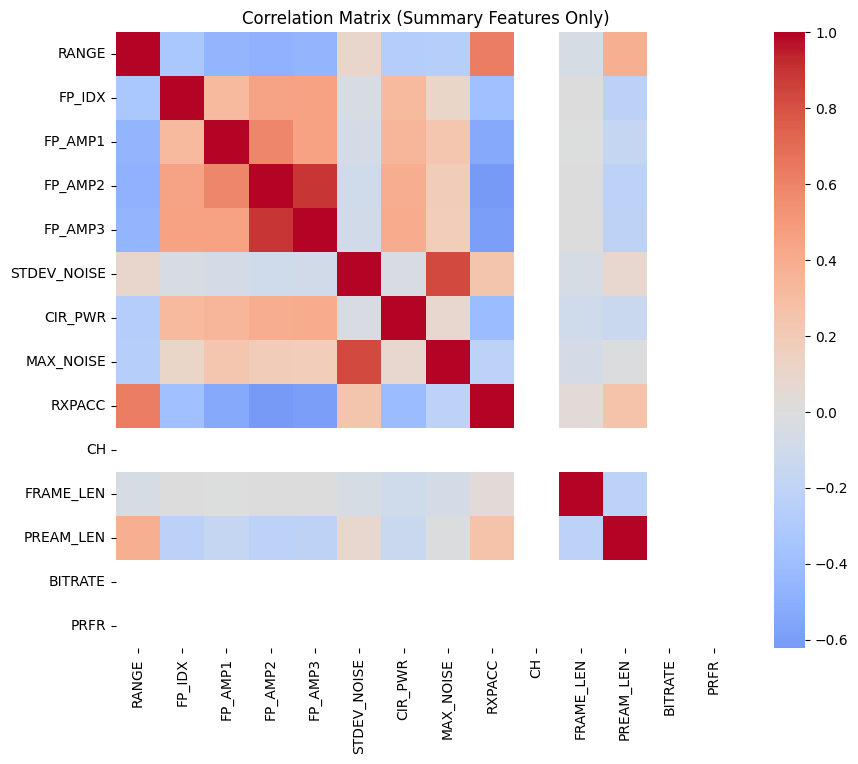

In [4]:
# 5) Correlation heatmap (optional, was jus trying this out)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), center=0, cmap="coolwarm")
plt.title("Correlation Matrix (Summary Features Only)")
plt.show()

In [5]:
# 6) Train/test split (prepares data for the modeling teammate)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Stop here for preprocessing-only responsibility.
# Teammates can continue with model training using X_train/X_test.

Train shape: (33600, 14)
Test shape: (8400, 14)
